# 18 · Naive Bayes

Mi amigo nos cancela mucho. Tengo un historial de 40 invitaciones y quiero predecir: **¿saldrá o nos cancelará?**

Los predictores son:
- `con_novia` — ¿está con la novia? (Sí/No)
- `llueve` — ¿está lloviendo? (Sí/No)
- `viernes` — ¿es viernes? (Sí/No)

La idea de **Naive Bayes**: usar la probabilidad de cada predictor *dado* el resultado para calcular la probabilidad del resultado *dado* los predictores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/friends.csv")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\n¿Sale? →\n{df['sale'].value_counts()}")

  con_novia llueve viernes sale  temperatura  hora_invitacion
0        Sí     Sí      No   No         21.7             20.0
1        No     No      No   No         18.9             18.8
2        No     Sí      Sí   Sí         26.6             15.6
3        No     No      Sí   Sí         30.1             17.8
4        Sí     Sí      Sí   Sí         23.1             13.4
5        Sí     No      Sí   Sí         23.1             13.4
6        Sí     No      No   No         15.7             17.6
7        No     No      No   No         23.3             20.6
8        No     No      No   Sí         22.1             12.8
9        No     Sí      No   Sí         26.2             15.4

Shape: (40, 6)

¿Sale? →
sale
No    20
Sí    20
Name: count, dtype: int64


## 1 · Exploración: ¿Qué patrones hay?

Veamos cómo se distribuye `sale` según cada predictor.

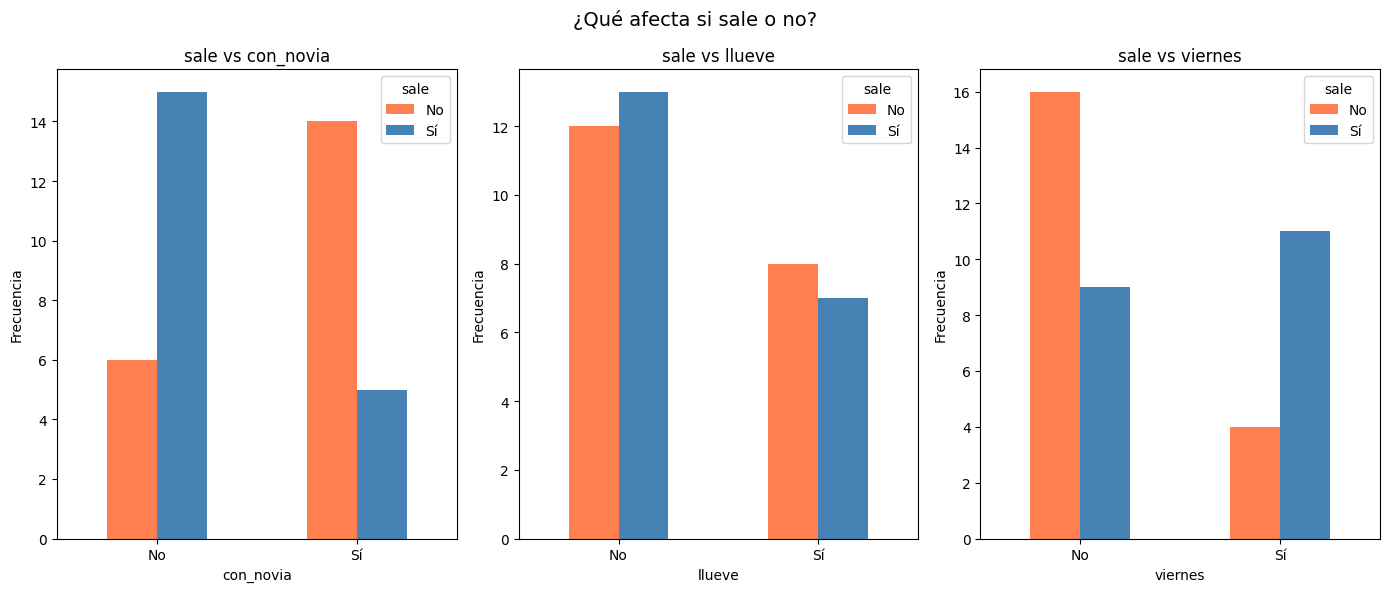

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes, ["con_novia", "llueve", "viernes"]):
    ct = pd.crosstab(df[col], df["sale"])
    ct.plot(kind="bar", ax=ax, color=["coral", "steelblue"], rot=0)
    ax.set_title(f"sale vs {col}")
    ax.set_ylabel("Frecuencia")
    ax.legend(title="sale")

plt.suptitle("¿Qué afecta si sale o no?", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# Tablas de frecuencia
for col in ["con_novia", "llueve", "viernes"]:
    print(f"--- {col} vs sale ---")
    print(pd.crosstab(df[col], df["sale"], margins=True))
    print()

--- con_novia vs sale ---
sale       No  Sí  All
con_novia             
No          6  15   21
Sí         14   5   19
All        20  20   40

--- llueve vs sale ---
sale    No  Sí  All
llueve             
No      12  13   25
Sí       8   7   15
All     20  20   40

--- viernes vs sale ---
sale     No  Sí  All
viernes             
No       16   9   25
Sí        4  11   15
All      20  20   40



## 2 · Bayes Exacto: Buscar Filas Idénticas

La forma más directa: buscar en el historial todos los casos con **exactamente** el mismo escenario y contar.

**Escenario**: con_novia=Sí, llueve=No, viernes=Sí → ¿sale?

In [4]:
ESCENARIO = {"con_novia": "Sí", "llueve": "No", "viernes": "Sí"}

mask = (
    (df["con_novia"] == ESCENARIO["con_novia"])
    & (df["llueve"] == ESCENARIO["llueve"])
    & (df["viernes"] == ESCENARIO["viernes"])
)

coincidencias = df[mask]
print(f"Escenario: {ESCENARIO}")
print(f"Filas que coinciden: {len(coincidencias)} de {len(df)}")
print()
print(coincidencias)
print(f"\nResultado: {coincidencias['sale'].value_counts().to_dict()}")

Escenario: {'con_novia': 'Sí', 'llueve': 'No', 'viernes': 'Sí'}
Filas que coinciden: 5 de 40

   con_novia llueve viernes sale  temperatura  hora_invitacion
5         Sí     No      Sí   Sí         23.1             13.4
10        Sí     No      Sí   Sí         22.1             12.8
19        Sí     No      Sí   No         22.9             20.5
22        Sí     No      Sí   No         12.5             16.3
29        Sí     No      Sí   Sí         22.8             13.3

Resultado: {'Sí': 3, 'No': 2}


In [5]:
# Problema: ¿y si buscamos un escenario con pocas o cero coincidencias?
ESCENARIO_RARO = {"con_novia": "Sí", "llueve": "Sí", "viernes": "No"}

mask_raro = (
    (df["con_novia"] == ESCENARIO_RARO["con_novia"])
    & (df["llueve"] == ESCENARIO_RARO["llueve"])
    & (df["viernes"] == ESCENARIO_RARO["viernes"])
)

print(f"Escenario: {ESCENARIO_RARO}")
print(f"Filas que coinciden: {len(df[mask_raro])} de {len(df)}")
print(f"Resultado: {df[mask_raro]['sale'].value_counts().to_dict()}")
print("\n→ Solo vemos una clase. No hay suficientes datos para estimar bien.")

Escenario: {'con_novia': 'Sí', 'llueve': 'Sí', 'viernes': 'No'}
Filas que coinciden: 5 de 40
Resultado: {'No': 5}

→ Solo vemos una clase. No hay suficientes datos para estimar bien.


## 3 · Teorema de Bayes

El método exacto falla con pocos datos. El **teorema de Bayes** resuelve esto invirtiendo la pregunta:

En vez de preguntar directamente $P(\text{sale} | X)$, calculamos:

$$P(\text{sale}=\text{Sí} | X) = \frac{P(X | \text{sale}=\text{Sí}) \cdot P(\text{sale}=\text{Sí})}{P(X)}$$

Donde:
- $P(\text{sale}=\text{Sí})$ → **prior**: ¿qué tan seguido sale en general?
- $P(X | \text{sale}=\text{Sí})$ → **likelihood**: ¿qué tan probable es ver este escenario entre las veces que SÍ sale?
- $P(X)$ → **evidence**: ¿qué tan probable es este escenario en general?
- $P(\text{sale}=\text{Sí} | X)$ → **posterior**: lo que queremos saber

In [6]:
# Prior: P(sale=Sí) y P(sale=No)
n = len(df)
p_si = (df["sale"] == "Sí").sum() / n
p_no = (df["sale"] == "No").sum() / n

print(f"P(sale=Sí) = {(df['sale'] == 'Sí').sum()}/{n} = {p_si:.2f}")
print(f"P(sale=No) = {(df['sale'] == 'No').sum()}/{n} = {p_no:.2f}")

P(sale=Sí) = 20/40 = 0.50
P(sale=No) = 20/40 = 0.50


## 4 · Lo "Naive": Asumir Independencia

Calcular $P(X | \text{sale})$ requiere buscar la combinación exacta de 3 predictores — el mismo problema de antes. 

El truco **naive** (ingenuo): asumir que los predictores son **independientes** dado el resultado:

$$P(\text{con\_novia}, \text{llueve}, \text{viernes} | \text{sale}) = P(\text{con\_novia} | \text{sale}) \cdot P(\text{llueve} | \text{sale}) \cdot P(\text{viernes} | \text{sale})$$

Ahora solo necesitamos contar **cada predictor por separado**, no las combinaciones. Con 40 filas esto es mucho más robusto.

In [7]:
# Tablas de probabilidad condicional: P(predictor | sale)
df_si = df[df["sale"] == "Sí"]
df_no = df[df["sale"] == "No"]
n_si = len(df_si)
n_no = len(df_no)

print(f"Filas donde sale=Sí: {n_si}")
print(f"Filas donde sale=No: {n_no}")
print()

for col in ["con_novia", "llueve", "viernes"]:
    p_col_si = (df_si[col] == "Sí").sum() / n_si
    p_col_no = (df_no[col] == "Sí").sum() / n_no
    print(
        f"P({col}=Sí | sale=Sí) = {(df_si[col] == 'Sí').sum()}/{n_si} = {p_col_si:.2f}"
    )
    print(
        f"P({col}=Sí | sale=No) = {(df_no[col] == 'Sí').sum()}/{n_no} = {p_col_no:.2f}"
    )
    print()

Filas donde sale=Sí: 20
Filas donde sale=No: 20

P(con_novia=Sí | sale=Sí) = 5/20 = 0.25
P(con_novia=Sí | sale=No) = 14/20 = 0.70

P(llueve=Sí | sale=Sí) = 7/20 = 0.35
P(llueve=Sí | sale=No) = 8/20 = 0.40

P(viernes=Sí | sale=Sí) = 11/20 = 0.55
P(viernes=Sí | sale=No) = 4/20 = 0.20



## 5 · Cálculo Manual Completo

Escenario: **con_novia=Sí, llueve=No, viernes=Sí** → ¿sale?

Calculamos $P(\text{sale}=\text{Sí} | X)$ y $P(\text{sale}=\text{No} | X)$ y comparamos.

In [8]:
# Escenario: con_novia=Sí, llueve=No, viernes=Sí
# Paso 1: P(cada predictor | sale=Sí)
p_novia_si__sale_si = (df_si["con_novia"] == "Sí").sum() / n_si
p_llueve_no__sale_si = (df_si["llueve"] == "No").sum() / n_si
p_viernes_si__sale_si = (df_si["viernes"] == "Sí").sum() / n_si

# Paso 2: P(cada predictor | sale=No)
p_novia_si__sale_no = (df_no["con_novia"] == "Sí").sum() / n_no
p_llueve_no__sale_no = (df_no["llueve"] == "No").sum() / n_no
p_viernes_si__sale_no = (df_no["viernes"] == "Sí").sum() / n_no

print("=== Likelihood: P(X | sale) ===")
print(f"P(con_novia=Sí | sale=Sí) = {p_novia_si__sale_si:.2f}")
print(f"P(llueve=No    | sale=Sí) = {p_llueve_no__sale_si:.2f}")
print(f"P(viernes=Sí   | sale=Sí) = {p_viernes_si__sale_si:.2f}")
print()
print(f"P(con_novia=Sí | sale=No) = {p_novia_si__sale_no:.2f}")
print(f"P(llueve=No    | sale=No) = {p_llueve_no__sale_no:.2f}")
print(f"P(viernes=Sí   | sale=No) = {p_viernes_si__sale_no:.2f}")

=== Likelihood: P(X | sale) ===
P(con_novia=Sí | sale=Sí) = 0.25
P(llueve=No    | sale=Sí) = 0.65
P(viernes=Sí   | sale=Sí) = 0.55

P(con_novia=Sí | sale=No) = 0.70
P(llueve=No    | sale=No) = 0.60
P(viernes=Sí   | sale=No) = 0.20


In [9]:
# Paso 3: Multiplicar (asunción naive) y combinar con prior
# P(X | sale=Sí) * P(sale=Sí)
likelihood_si = p_novia_si__sale_si * p_llueve_no__sale_si * p_viernes_si__sale_si
score_si = likelihood_si * p_si

# P(X | sale=No) * P(sale=No)
likelihood_no = p_novia_si__sale_no * p_llueve_no__sale_no * p_viernes_si__sale_no
score_no = likelihood_no * p_no

print("=== Paso 3: likelihood * prior ===")
print(
    f"Score(Sí) = {p_novia_si__sale_si:.2f} × {p_llueve_no__sale_si:.2f} × {p_viernes_si__sale_si:.2f} × {p_si:.2f} = {score_si:.4f}"
)
print(
    f"Score(No) = {p_novia_si__sale_no:.2f} × {p_llueve_no__sale_no:.2f} × {p_viernes_si__sale_no:.2f} × {p_no:.2f} = {score_no:.4f}"
)

# Paso 4: Normalizar para obtener probabilidades
total = score_si + score_no
prob_si = score_si / total
prob_no = score_no / total

print(f"\n=== Paso 4: Normalizar ===")
print(f"P(sale=Sí | X) = {score_si:.4f} / {total:.4f} = {prob_si:.2%}")
print(f"P(sale=No | X) = {score_no:.4f} / {total:.4f} = {prob_no:.2%}")
print(
    f"\n→ Predicción: {'Sí sale' if prob_si > prob_no else 'No sale'} ({max(prob_si, prob_no):.1%})"
)

=== Paso 3: likelihood * prior ===
Score(Sí) = 0.25 × 0.65 × 0.55 × 0.50 = 0.0447
Score(No) = 0.70 × 0.60 × 0.20 × 0.50 = 0.0420

=== Paso 4: Normalizar ===
P(sale=Sí | X) = 0.0447 / 0.0867 = 51.55%
P(sale=No | X) = 0.0420 / 0.0867 = 48.45%

→ Predicción: Sí sale (51.6%)


## 6 · Verificación con sklearn

`CategoricalNB` hace exactamente lo mismo que calculamos a mano. Verifiquemos que coincide.

In [10]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

# Codificar Sí/No como 0/1
enc = OrdinalEncoder(categories=[["No", "Sí"]] * 3)
X_encoded = enc.fit_transform(df[["con_novia", "llueve", "viernes"]])

enc_y = OrdinalEncoder(categories=[["No", "Sí"]])
y_encoded = enc_y.fit_transform(df[["sale"]]).ravel()

# Entrenar CategoricalNB
model = CategoricalNB(
    alpha=1e-10
)  # alpha~0 para que coincida con nuestro cálculo sin suavizado
model.fit(X_encoded, y_encoded)

# Predecir el mismo escenario: con_novia=Sí(1), llueve=No(0), viernes=Sí(1)
escenario_encoded = np.array([[1, 0, 1]])
proba = model.predict_proba(escenario_encoded)[0]

print("sklearn CategoricalNB:")
print(f"  P(sale=No | X) = {proba[0]:.2%}")
print(f"  P(sale=Sí | X) = {proba[1]:.2%}")
print(f"\nCálculo manual:")
print(f"  P(sale=No | X) = {prob_no:.2%}")
print(f"  P(sale=Sí | X) = {prob_si:.2%}")
print(f"\n{'✅ Coinciden!' if abs(proba[1] - prob_si) < 0.01 else '❌ Difieren'}")

sklearn CategoricalNB:
  P(sale=No | X) = 48.45%
  P(sale=Sí | X) = 51.55%

Cálculo manual:
  P(sale=No | X) = 48.45%
  P(sale=Sí | X) = 51.55%

✅ Coinciden!


## 7 · Todas las Combinaciones Posibles

Solo hay $2^3 = 8$ escenarios posibles. Veamos la predicción para cada uno.

In [11]:
from itertools import product

combos = list(product(["No", "Sí"], repeat=3))
results = []

for novia, lluvia, vier in combos:
    x = pd.DataFrame(
        [[novia, lluvia, vier]], columns=["con_novia", "llueve", "viernes"]
    )
    x_enc = enc.transform(x)
    proba = model.predict_proba(x_enc)[0]
    results.append(
        {
            "con_novia": novia,
            "llueve": lluvia,
            "viernes": vier,
            "P(sale=Sí)": f"{proba[1]:.1%}",
            "Predicción": "Sí sale" if proba[1] > 0.5 else "No sale",
        }
    )

tabla = pd.DataFrame(results)
print(tabla.to_string(index=False))

con_novia llueve viernes P(sale=Sí) Predicción
       No     No      No      60.4%    Sí sale
       No     No      Sí      88.2%    Sí sale
       No     Sí      No      55.2%    Sí sale
       No     Sí      Sí      85.7%    Sí sale
       Sí     No      No      17.9%    No sale
       Sí     No      Sí      51.6%    Sí sale
       Sí     Sí      No      15.0%    No sale
       Sí     Sí      Sí      46.2%    No sale


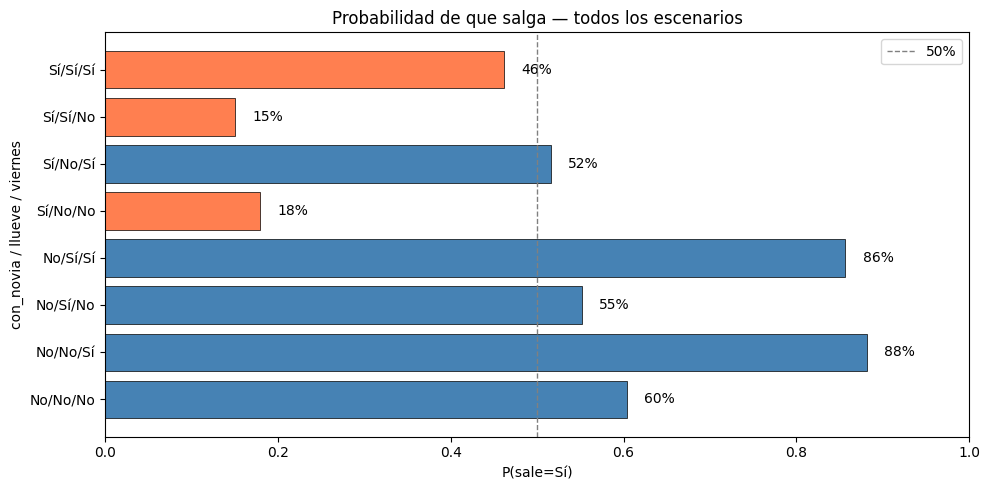

In [12]:
# Visualizar las probabilidades
fig, ax = plt.subplots(figsize=(10, 5))

labels = [f"{r['con_novia']}/{r['llueve']}/{r['viernes']}" for _, r in tabla.iterrows()]
probs = [float(r["P(sale=Sí)"].strip("%")) / 100 for _, r in tabla.iterrows()]
colors = ["steelblue" if p > 0.5 else "coral" for p in probs]

bars = ax.barh(labels, probs, color=colors, edgecolor="k", linewidth=0.5)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="50%")
ax.set_xlabel("P(sale=Sí)")
ax.set_ylabel("con_novia / llueve / viernes")
ax.set_title("Probabilidad de que salga — todos los escenarios")
ax.set_xlim(0, 1)
ax.legend()

for bar, p in zip(bars, probs):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{p:.0%}",
        va="center",
    )

plt.tight_layout()
plt.show()

## 8 · Resumen

| Concepto | Descripción |
|----------|-------------|
| Prior | $P(Y)$ — probabilidad base sin ver predictores |
| Likelihood | $P(X \mid Y)$ — probabilidad de los predictores dado el resultado |
| Posterior | $P(Y \mid X)$ — lo que queremos: probabilidad del resultado dados los predictores |
| Naive | Asumir independencia entre predictores: $P(X_1, X_2, X_3 \mid Y) = \prod P(X_i \mid Y)$ |
| Normalización | Dividir por la suma de scores para obtener probabilidades reales |

| Ventaja | Limitación |
|---------|-----------|
| Funciona bien con pocos datos | Asume independencia (a veces es falso) |
| Rápido de entrenar y predecir | Solo con variables categóricas (versión estándar) |
| No necesita muchas filas por combinación | No captura interacciones entre predictores |

> 👈 Naive Bayes es sorprendentemente efectivo en la práctica, incluso cuando la asunción de independencia no se cumple perfectamente.